In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, r2_score, mean_absolute_error, mean_squared_error, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [64]:
df = pd.read_excel(r'C:\Users\VUONG\Desktop\hub\Data sau khi điền khuyết thiếu.xlsx').drop(columns = ['No']).dropna()
df.head()

,A1,A2,A3,A4,A5,SQ1,SQ2,SQ3,SQ4,SQ5,SQ6,SQ7,SQ8,SAT1,SAT2,ATT1,ATT2,BI1,BI2
0,1,0,2,0,2,5,5,5,4,5,5,5,5,5,4,5,5,5,5
1,0,0,2,0,3,5,5,5,5,5,5,5,5,5,5,5,5,5,5
2,1,0,1,2,0,5,4,3,5,4,4,5,5,4,4,4,5,3,5
3,1,2,1,2,2,5,4,3,4,4,5,5,5,4,4,4,3,3,4
4,1,0,1,0,0,4,4,5,5,4,5,5,5,5,4,4,4,5,5


# Train Test Split

In [65]:
X = df.drop(columns = ['ATT1'])
y = df['ATT1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True)

In [66]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.497
RMSE: 0.872
MAE: 0.611


# Logistic Regression

In [68]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

In [69]:
print(f"Độ chính xác: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Độ chính xác: 0.615
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         8
           2       0.29      0.33      0.31         6
           3       0.55      0.61      0.58        18
           4       0.56      0.66      0.60        29
           5       0.77      0.67      0.71        30

    accuracy                           0.62        91
   macro avg       0.63      0.55      0.57        91
weighted avg       0.65      0.62      0.62        91



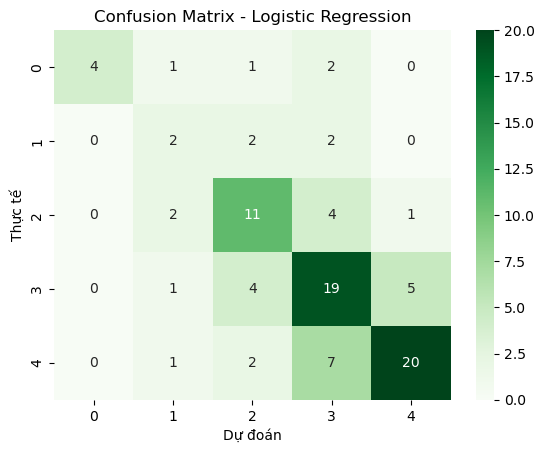

In [70]:
# Trực quan hóa số lần mô hình dự đoán đúng
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

# KMeans Clustering

In [71]:
X_cluster = df[['SQ1','SQ2','SQ3','SQ4','SQ5','SQ6','SQ7','SQ8','SAT1','SAT2','ATT1','ATT2','BI1','BI2']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [72]:
sil_score = silhouette_score(X_scaled, df['Cluster'])
dbi = davies_bouldin_score(X_scaled, df['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df['Cluster'])

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {dbi:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.3f}")

Silhouette Score: 0.163
Davies-Bouldin Index: 1.641
Calinski-Harabasz Index: 119.105


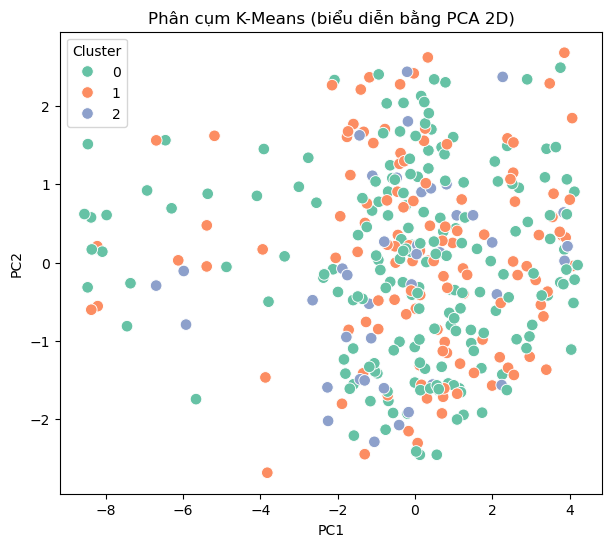

In [73]:
# Sử dụng PCA để giảm chiều dữ liệu và trực quan hóa các Clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

plt.figure(figsize=(7,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='Set2', s=70)
plt.title('Phân cụm K-Means (biểu diễn bằng PCA 2D)')
plt.show()
